# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

$
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
$

где \(\sigma(z)\) — сигмоида:

$
\sigma(z) = \frac{1}{1 + e^{-z}}
$

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

$
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
$

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


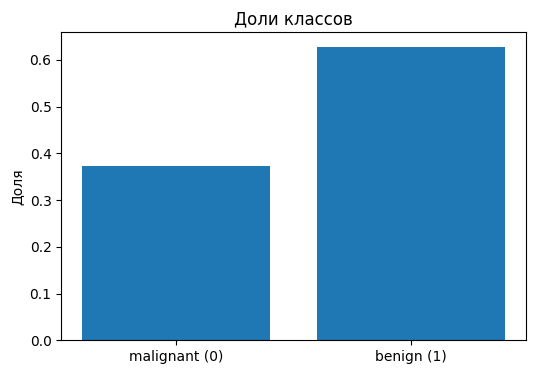

In [3]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [4]:
# YOUR CODE HERE
# 1) Разбейте данные на train/test
# 2) Создайте scaler
# 3) Обучите scaler на train
# 4) Преобразуйте X_train и X_test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [5]:
def sigmoid(z):
    # YOUR CODE HERE
    return 1 / (1 + np.exp(-z))

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

$
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
$

In [6]:
def compute_log_loss(y_true, y_pred_proba):
    # YOUR CODE HERE
    y_pred_proba = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    return -1 / len(y_true) * np.sum(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba), axis=0)

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- $z = Xw + b$
- $\hat{p} = \sigma(z)$

Градиенты для log-loss:
$
dw = \frac{1}{n} X^T(\hat{p} - y), \qquad db = \frac{1}{n}\sum(\hat{p} - y)
$

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [7]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    # 1) посчитать z
    # 2) посчитать p = sigmoid(z)
    # 3) посчитать loss
    # 4) посчитать dw и db
    z = X @ w + b
    p = sigmoid(z)
    loss = compute_log_loss(y, p)
    dw = 1 / len(y) * X.T @ (p - y)
    db = 1 / len(y) * np.sum(p - y, axis=0)
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [8]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        # 2) в цикле вызовите forward_backward
        # 3) обновите параметры
        # 4) сохраните loss в self.loss_history
        self.w = np.zeros(shape=X.shape[1], dtype=np.float64)
        self.b = np.float64(0)
        for i in range(self.n_iters):
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)
            self.loss_history.append(loss)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
        return self

    def predict_proba(self, X):
        # YOUR CODE HERE
        proba = sigmoid(X @ self.w + self.b)
        return proba

    def predict(self, X):
        # YOUR CODE HERE
        preds = np.where(self.predict_proba(X) > self.threshold, 1.0, 0.0)
        return preds

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

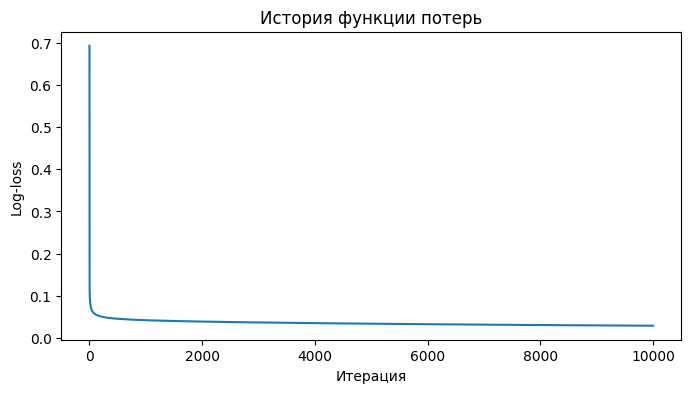

In [9]:
my_model = MyLogisticRegressionGD(
    learning_rate=1,   # подберите разумное значение
    n_iters=10000,         # задайте число итераций
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [10]:
# YOUR CODE HERE
my_proba_test = my_model.predict_proba(X_test_scaled)
my_pred_test = my_model.predict(X_test_scaled)

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test)
}

pd.Series(my_metrics).round(4)

accuracy     0.9649
precision    0.9722
recall       0.9722
f1           0.9722
roc_auc      0.9911
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

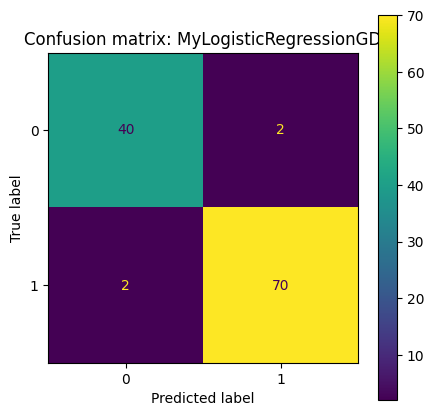

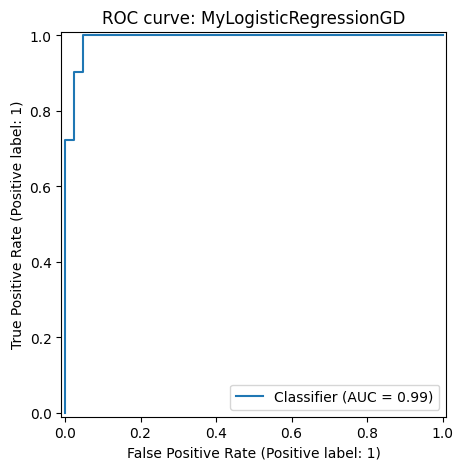

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [12]:
sk_model = LogisticRegression(max_iter=10000, random_state=42)

# YOUR CODE HERE
# 1) обучите sk_model
# 2) получите вероятности и классы на test
# 3) посчитайте те же метрики

sk_model.fit(X_train, y_train)

sk_proba_test = sk_model.predict_proba(X_test)[:,1]
sk_pred_test = sk_model.predict(X_test)

sk_metrics = {
    "accuracy": accuracy_score(y_test, sk_pred_test),
    "precision": precision_score(y_test, sk_pred_test),
    "recall": recall_score(y_test, sk_pred_test),
    "f1": f1_score(y_test, sk_pred_test),
    "roc_auc": roc_auc_score(y_test, sk_proba_test),
}

pd.Series(sk_metrics).round(4)

accuracy     0.9649
precision    0.9595
recall       0.9861
f1           0.9726
roc_auc      0.9954
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [13]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9649,0.9722,0.9722,0.9722,0.9911
sklearn,0.9649,0.9595,0.9861,0.9726,0.9954


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,7.132886,-0.205227,7.338114
13,area error,-4.447479,-0.096877,4.350601
10,radius error,-4.394847,-0.058288,4.336560
16,concavity error,4.026060,-0.031925,4.057984
23,worst area,-4.055867,-0.014430,4.041438
26,worst concavity,-4.614508,-1.313390,3.301118
17,concave points error,-3.201789,-0.034571,3.167218
21,worst texture,-3.329623,-0.376140,2.953484
20,worst radius,-2.558926,0.086970,2.645895
9,mean fractal dimension,-2.454842,-0.032344,2.422497


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [14]:
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    # YOUR CODE HERE
    my_pred_proba = my_model.predict_proba(X_test_scaled)
    pred_thr = (my_pred_proba >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1": f1_score(y_test, pred_thr)
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3,0.9825,0.9730,1.0000,0.9863
1,0.5,0.9649,0.9722,0.9722,0.9722
2,0.7,0.9561,0.9718,0.9583,0.9650


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему для логистической регрессии используется сигмоида?
2. Почему в этой задаче мы считаем **log-loss**, а не MSE?
3. Зачем стандартизировать признаки перед обучением градиентным спуском?
4. Насколько близки метрики вашей реализации к `scikit-learn`?
5. Почему библиотечная модель обычно работает стабильнее и быстрее?
6. Как изменение порога влияет на precision и recall?
7. В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?

## Ответы
1. Это нужно для того, чтобы перевести величину от -$\infty$ до $+\infty$ в интервал $[0,1]$ (в вероятность положительного класса) чтобы потом в зависимоти от порога предсказать метку класса.
2. Потому что мы работаем с вероятностями, так что можем применить метод максимального правдоподобия.
3. Признаки нужно стандартизировать, чтобы при обучении никакой из признаков не получал приимущества (большого веса) только из за своей большой дисперсии относительно других признаков.
4. Метрики очень близки (у sklearn лучше recall и roc_auc, a у моей лучше precision).
5. Во-первых, для модели из sklearn по умолчанию применяется L2 регуляризация (за это отвечает параметры `l1_ratio` и `C` в `LogisticRegression`), во-вторых, в модели из sklearn по умолчанию не простой градиентный спуск, а некоторый Limited-memory Broyden–Fletcher–Goldfarb–Shanno Algorithm (я пока что не разобрался, что в нем происходит).
6. Precision вырос при уменьшении порога, как и recall.
7. Логистическая регрессия хороша, когда данные разделимы линейно или хотя бы полиномиально (можно например применить кубическую аппроксимацию), логистическая регрессия очень хорошо интерпретируема и уступает другим моделям при очень большом числе признаков у малого объема данных (модель переобучается).

## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

## Задание А / C
Ниже реализован класс с возможностью предоставить свою step функцию и такая функция для L2 регуляризации. Также я добавил параметр `tolerance` и атрибут `last_pred_proba` чтобы можно было нагляднее сравнивать модели скорость их обучения.

In [15]:
class MyLogisticRegressionGDCustom(MyLogisticRegressionGD):
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5, tolerance=1e-15, GD_step_func=forward_backward, GD_params=None):
        super().__init__(learning_rate, n_iters, threshold)
        self.step_func = GD_step_func
        self.GD_params=GD_params
        self.tolerance = tolerance
    
    def fit(self, X, y):
        self.w = np.zeros(shape=X.shape[1], dtype=np.float64)
        self.b = np.float64(0)
        for i in range(self.n_iters):
            if(self.GD_params == None):
                p, loss, dw, db = self.step_func(X, y, self.w, self.b)
            else:
                p, loss, dw, db = self.step_func(X, y, self.w, self.b, params=self.GD_params)
            if(np.linalg.norm(dw) + np.abs(db) < self.tolerance):
                break
            self.loss_history.append(loss)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
        return self
    
    def predict(self, X):
        self.last_pred_proba = self.predict_proba(X)
        preds = np.where(self.last_pred_proba > self.threshold, 1.0, 0.0)
        return preds
    
def forward_backward_L2(X, y, w, b, params):
    z = X @ w + b
    p = sigmoid(z)
    loss = compute_log_loss(y, p) + params['lambda'] * np.sum(w ** 2)
    dw = 1 / len(y) * (X.T @ (p - y)) + 2 * w * params['lambda']
    db = 1 / len(y) * np.sum(p - y, axis=0) + 2 * b * params['lambda']
    return p, loss, dw, db

Теперь обучим самодельную модель с L2 и без и сравним результаты:

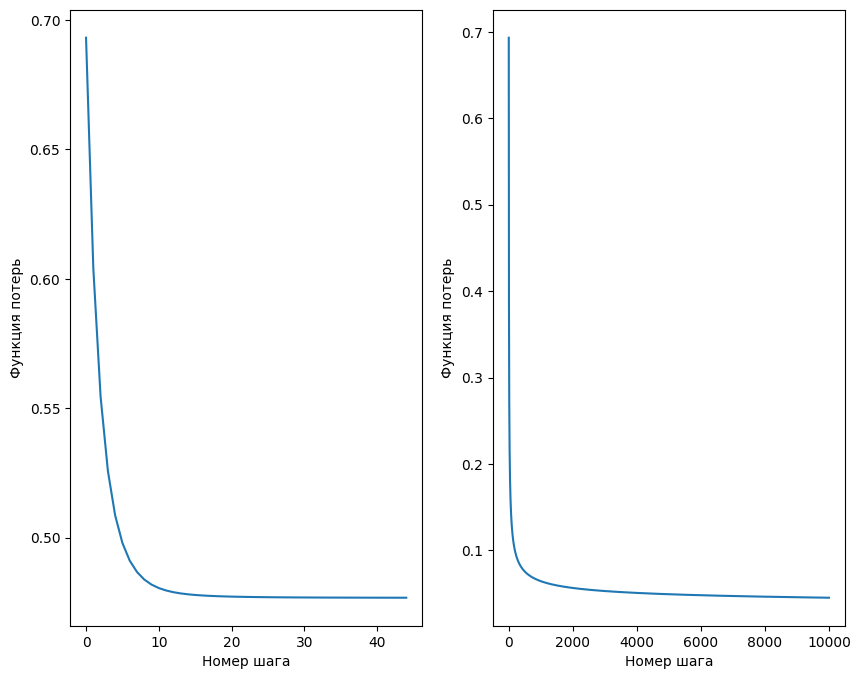

In [16]:
my_model_l2 = MyLogisticRegressionGDCustom(n_iters=10000, threshold=0.3, tolerance=0.001, GD_step_func=forward_backward_L2, GD_params={'lambda' : 1})
my_model_stock = MyLogisticRegressionGDCustom(n_iters=10000, threshold=0.3, tolerance=0.001)

my_model_l2.fit(X_train_scaled, y_train)
my_model_stock.fit(X_train_scaled, y_train)

axes = plt.figure(figsize=(10, 8)).subplots(1, 2).ravel()

axes[0].plot(my_model_l2.loss_history)
axes[0].set_xlabel('Номер шага')
axes[0].set_ylabel('Функция потерь')
axes[0].set_label('История потерь модели с L2')

axes[1].plot(my_model_stock.loss_history)
axes[1].set_xlabel('Номер шага')
axes[1].set_ylabel('Функция потерь')
axes[1].set_label('История потерь модели без L2')

plt.show()


Видно, что модель с L2 обучилась сильно быстрее. Посмотрим теперь на score.

In [17]:
def print_model_scores(pred, pred_proba, test):
    metrics = {
        'accuracy' : accuracy_score(test, pred),
        'precision' : precision_score(test, pred),
        'recall' : recall_score(test, pred),
        'f1' : f1_score(test, pred),
        'roc_auc' : roc_auc_score(test, pred_proba)
    }
    print(pd.Series(metrics).round(4))

print('L2 metrics:')
print_model_scores(my_model_l2.predict(X_test_scaled), my_model_l2.last_pred_proba, y_test)
print('\nStock model metrics:')
print_model_scores(my_model_stock.predict(X_test_scaled), my_model_l2.last_pred_proba, y_test)

L2 metrics:
accuracy     0.8684
precision    0.8276
recall       1.0000
f1           0.9057
roc_auc      0.9907
dtype: float64

Stock model metrics:
accuracy     0.9912
precision    0.9863
recall       1.0000
f1           0.9931
roc_auc      0.9907
dtype: float64


Видно, что модель с L2 обучалась слишком быстро, попробуем подобрать коэффициенты получше.

In [18]:
my_model_l2 = MyLogisticRegressionGDCustom(n_iters=10000, threshold=0.3, tolerance=0.001, GD_step_func=forward_backward_L2, GD_params={'lambda' : 0.01})
my_model_l2.fit(X_train_scaled, y_train)

print('L2 metrics:')
print_model_scores(my_model_l2.predict(X_test_scaled), my_model_l2.last_pred_proba, y_test)

L2 metrics:
accuracy     0.9649
precision    0.9474
recall       1.0000
f1           0.9730
roc_auc      0.9957
dtype: float64


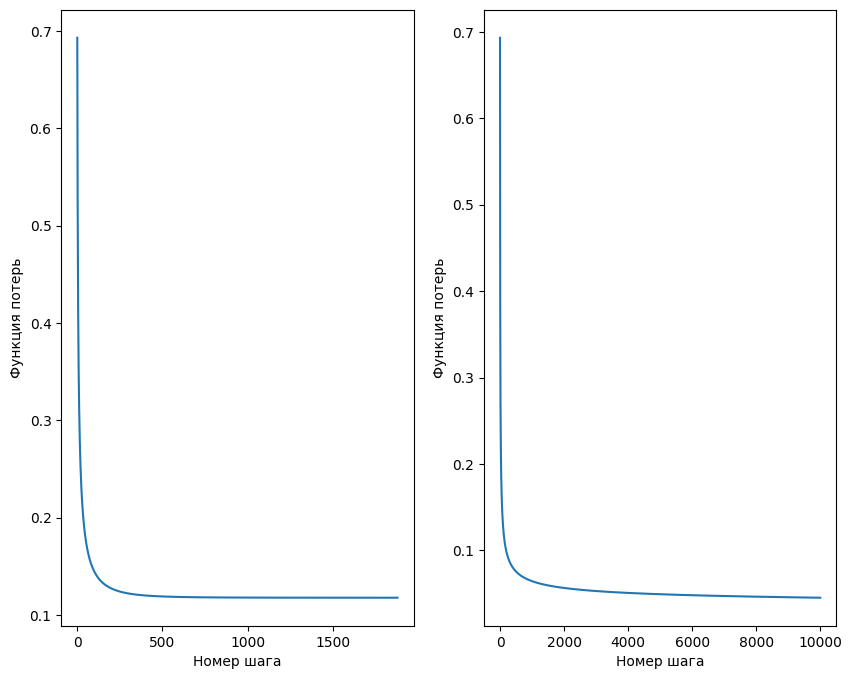

In [19]:
axes = plt.figure(figsize=(10, 8)).subplots(1, 2).ravel()

axes[0].plot(my_model_l2.loss_history)
axes[0].set_xlabel('Номер шага')
axes[0].set_ylabel('Функция потерь')
axes[0].set_label('История потерь модели с L2')

axes[1].plot(my_model_stock.loss_history)
axes[1].set_xlabel('Номер шага')
axes[1].set_ylabel('Функция потерь')
axes[1].set_label('История потерь модели без L2')

Получилось быстрее, но не настолько точно, как без L2. Если дальше уменьшать параметр lambda (где то на 0.0001), то получится тот же самый score, что и у обычной модели.

## Задание B
Теперь посмотрим на вклад признаков в предсказание модели:

In [20]:
weights_table = pd.DataFrame(data.feature_names).join(pd.DataFrame(my_model_stock.w), lsuffix='_')
weights_table.columns = ['feature_name', 'weight_value']
weights_table = weights_table.sort_values(by='weight_value', ascending=False, key=lambda col: col.abs())
weights_table


,feature_name,weight_value
21,worst texture,-1.661549
10,radius error,-1.474645
28,worst symmetry,-1.350493
27,worst concave points,-1.264638
23,worst area,-1.254868
13,area error,-1.244075
20,worst radius,-1.231892
24,worst smoothness,-1.129461
26,worst concavity,-1.107141
22,worst perimeter,-0.997511


Видно, что наибольший вклад сделали в основном предельные признаки (worst).

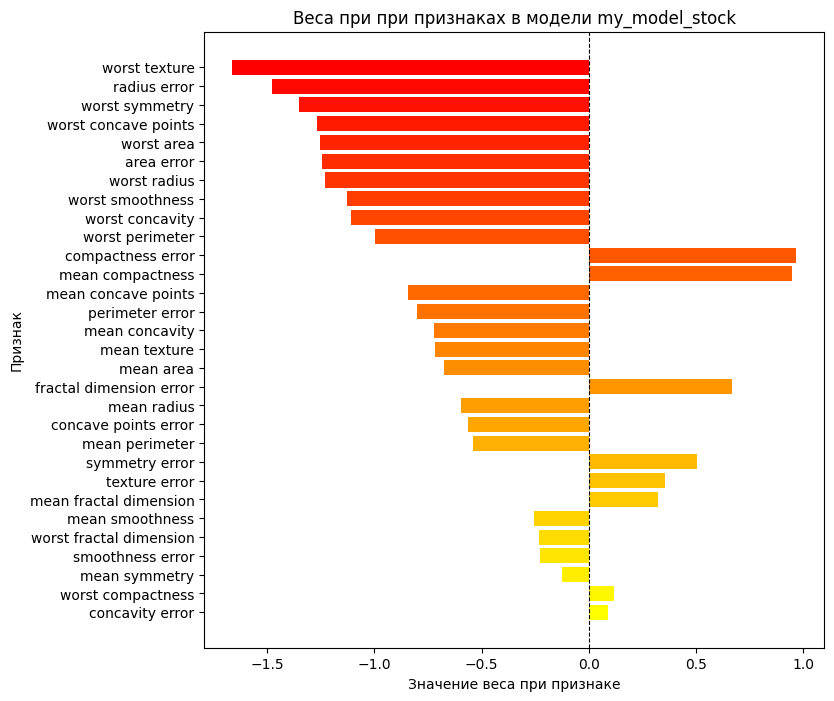

In [21]:

weights_dict = {name: value for name, value in zip(weights_table['feature_name'], weights_table['weight_value'])}

ax = plt.figure(figsize=(8,8)).add_subplot()
colors = plt.cm.autumn(np.linspace(0, 1, len(weights_dict)))
ax.barh(range(len(weights_dict)), weights_dict.values(), color=colors)
ax.set_yticks(range(len(weights_dict)))
ax.set_yticklabels(weights_dict.keys())
ax.set_title('Веса при при признаках в модели my_model_stock')
ax.set_ylabel('Признак')
ax.set_xlabel('Значение веса при признаке')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.show()

## Задание C
Посмотрим что будет при разных параметрах `learning_rate` и `n_iters` у модели без L2:

In [22]:
learning_data = []
warning_count_fit = 0
warning_count_predict = 0
last_warning = None
warnings.simplefilter("always")

for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]:
    for n_iters in range(100, 2000, 100):
        metrics_and_data = {}
        model = MyLogisticRegressionGDCustom(learning_rate=learning_rate, n_iters=n_iters, threshold=0.3, tolerance=0.0001)

        with warnings.catch_warnings(record=True) as w:
            model.fit(X_train_scaled, y_train)
            warning_count_fit += len(w)
            if(len(w) > 0):
                last_warning = w[-1]
        
        metrics_and_data['steps'] = len(model.loss_history)
        metrics_and_data['loss_history'] = model.loss_history

        with warnings.catch_warnings(record=True) as w:
            pred = model.predict(X_test_scaled)
            warning_count_predict += len(w)
            if(len(w) > 0):
                last_warning = w[-1]
        
        metrics_and_data['accuracy'] = accuracy_score(y_test, pred)
        metrics_and_data['precision'] = precision_score(y_test, pred)
        metrics_and_data['recall'] = recall_score(y_test, pred)
        metrics_and_data['f1'] = f1_score(y_test, pred)
        metrics_and_data['roc_auc'] = roc_auc_score(y_test, model.last_pred_proba)
        metrics_and_data['learning_rate'] = model.learning_rate
        metrics_and_data['n_iters'] = model.n_iters
        learning_data.append(metrics_and_data)

print('Raised warnings: during fit - ', warning_count_fit, '  during predict - ', warning_count_predict)
if(last_warning != None):
    print(last_warning)

Raised warnings: during fit -  40563   during predict -  40
{message : RuntimeWarning('overflow encountered in exp'), category : 'RuntimeWarning', filename : 'C:\\Users\\anton\\AppData\\Local\\Temp\\ipykernel_23904\\2375642462.py', lineno : 3, line : None}


Предупреждения возникают из-за переполнения в `np.exp()` при очень больших `learning_rate` (я скрыл их).

In [23]:
df_learning_data = pd.DataFrame(learning_data)
df_learning_data.head()

,steps,loss_history,accuracy,precision,recall,f1,roc_auc,learning_rate,n_iters
0,100,"[0.6931471805599453, 0.6929425590201165, 0.692...",0.631579,0.631579,1.0,0.774194,0.984788,0.0001,100
1,200,"[0.6931471805599453, 0.6929425590201165, 0.692...",0.631579,0.631579,1.0,0.774194,0.985119,0.0001,200
2,300,"[0.6931471805599453, 0.6929425590201165, 0.692...",0.631579,0.631579,1.0,0.774194,0.985119,0.0001,300
3,400,"[0.6931471805599453, 0.6929425590201165, 0.692...",0.640351,0.637168,1.0,0.778378,0.985119,0.0001,400
4,500,"[0.6931471805599453, 0.6929425590201165, 0.692...",0.640351,0.637168,1.0,0.778378,0.985450,0.0001,500


Посмотрим, как максимумы метрик зависят от `learning_rate` (максимумы берутся для каждого фиксированного `learning_rate`):

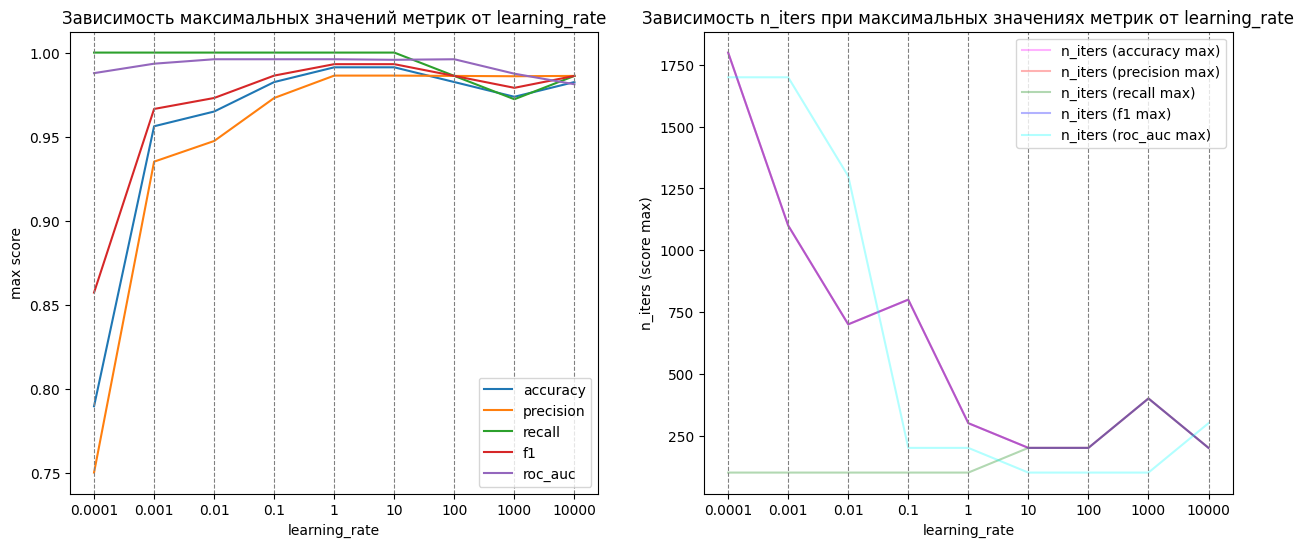

In [24]:
max_indices = [df_learning_data[df_learning_data['learning_rate'] == rate].drop(columns=['steps', 'loss_history', 'learning_rate', 'n_iters']).idxmax() for rate in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]]

max_values_data = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
n_iters_data = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

for indices in max_indices:
    max_values_data['accuracy'].append(df_learning_data.iloc[indices['accuracy']]['accuracy'])
    max_values_data['precision'].append(df_learning_data.iloc[indices['precision']]['precision'])
    max_values_data['recall'].append(df_learning_data.iloc[indices['recall']]['recall'])
    max_values_data['f1'].append(df_learning_data.iloc[indices['f1']]['f1'])
    max_values_data['roc_auc'].append(df_learning_data.iloc[indices['roc_auc']]['roc_auc'])

    n_iters_data['accuracy'].append(df_learning_data.iloc[indices['accuracy']]['n_iters'])
    n_iters_data['precision'].append(df_learning_data.iloc[indices['precision']]['n_iters'])
    n_iters_data['recall'].append(df_learning_data.iloc[indices['recall']]['n_iters'])
    n_iters_data['f1'].append(df_learning_data.iloc[indices['f1']]['n_iters'])
    n_iters_data['roc_auc'].append(df_learning_data.iloc[indices['roc_auc']]['n_iters'])
    
axes = plt.figure(figsize=(15, 6)).subplots(1, 2)

axes[0].set_xlabel('learning_rate')
axes[0].set_ylabel('max score')
axes[0].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], max_values_data['accuracy'], label='accuracy')
axes[0].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], max_values_data['precision'], label='precision')
axes[0].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], max_values_data['recall'], label='recall')
axes[0].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], max_values_data['f1'], label='f1')
axes[0].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], max_values_data['roc_auc'], label='roc_auc')
axes[0].legend(loc='lower right')
axes[0].set_title('Зависимость максимальных значений метрик от learning_rate')
for x in ['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000']:
    axes[0].axvline(x=x, color='grey', linestyle='--', linewidth=0.8)

axes[1].set_xlabel('learning_rate')
axes[1].set_ylabel('n_iters (score max)')
axes[1].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], n_iters_data['accuracy'], label='n_iters (accuracy max)', color=('magenta', 0.3))
axes[1].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], n_iters_data['precision'], label='n_iters (precision max)', color=('red', 0.3))
axes[1].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], n_iters_data['recall'], label='n_iters (recall max)', color=('green', 0.3))
axes[1].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], n_iters_data['f1'], label='n_iters (f1 max)', color=('blue', 0.3))
axes[1].plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], n_iters_data['roc_auc'], label='n_iters (roc_auc max)', color=('cyan', 0.3))
axes[1].legend(loc='upper right')
axes[1].set_title('Зависимость n_iters при максимальных значениях метрик от learning_rate')
for x in ['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000']:
    axes[1].axvline(x=x, color='grey', linestyle='--', linewidth=0.8)

plt.show()

Получилось, что оптимальные метрики достигаются при `lerning_rate` при значениях 1 и 10 (и скорее всего между ними). Оптимальные значения `n_iters` также совпадают для всех метрик кроме roc_auc и recall(и оптимальное число `n_iters` уменьшается при увеличении `learning_rate`, что логично). С recall происходит такое, потому что recall имеет формулу:

$
    recall = \frac{TP}{TP + FN}
$

И результат таков, что модель просто классифицирует все семплы как элементы класса 0 (т.е. $FN = 0$), потому что веса близки к нулю, то есть вероятность класса 1 сама близка к нулю. То есть для максимизации метрики recall просто не нужно обучаться дальше нулевых весов. Теперь посмотрим еще на средние значения метрик в зависимости от `learning_rate`:

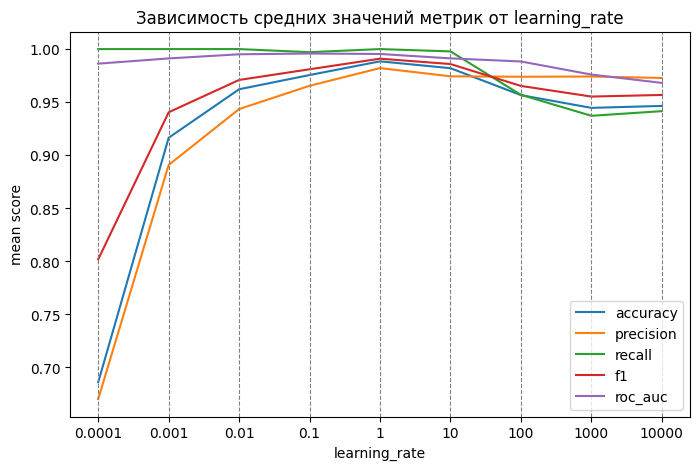

In [25]:
mean_values = [df_learning_data[df_learning_data['learning_rate'] == rate].drop(columns=['steps', 'loss_history', 'learning_rate', 'n_iters']).mean() for rate in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]]

mean_values_data = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
for values in mean_values:
    mean_values_data['accuracy'].append(values['accuracy'])
    mean_values_data['precision'].append(values['precision'])
    mean_values_data['recall'].append(values['recall'])
    mean_values_data['f1'].append(values['f1'])
    mean_values_data['roc_auc'].append(values['roc_auc'])

ax = plt.figure(figsize=(8, 5)).add_subplot()
ax.set_xlabel('learning_rate')
ax.set_ylabel('mean score')
ax.plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], mean_values_data['accuracy'], label='accuracy')
ax.plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], mean_values_data['precision'], label='precision')
ax.plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], mean_values_data['recall'], label='recall')
ax.plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], mean_values_data['f1'], label='f1')
ax.plot(['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000'], mean_values_data['roc_auc'], label='roc_auc')
ax.legend(loc='lower right')
ax.set_title('Зависимость средних значений метрик от learning_rate')
for x in ['0.0001', '0.001', '0.01', '0.1', '1', '10', '100', '1000', '10000']:
    ax.axvline(x=x, color='grey', linestyle='--', linewidth=0.8)


Этот график схож с предыдущим и также показывает, что оптимальные значения для `learning_rate` скорее всего где-то в $[1,10]$ (**Именно при n_iters <= 2000!!!**).

На последок поcмотрим на сходимость моделей с разными `learning_rate` при `tolerance` = 0.001. Для этого посмотрим на значение 'steps' (то есть длины `loss_history`) при различных `learning_rate` с большим n_iters (= 100000):

In [26]:
learning_data_convg = []
warning_count_fit = 0
warning_count_predict = 0
last_warning = None
warnings.simplefilter("always")

for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]:
    metrics_and_data = {}
    model = MyLogisticRegressionGDCustom(learning_rate=learning_rate, threshold=0.3, tolerance=0.001, n_iters=100000)
    
    with warnings.catch_warnings(record=True) as w:
            model.fit(X_train_scaled, y_train)
            warning_count_fit += len(w)
            if(len(w) > 0):
                last_warning = w[-1]

    metrics_and_data['steps'] = len(model.loss_history)
    metrics_and_data['loss_history'] = model.loss_history
    
    with warnings.catch_warnings(record=True) as w:
            pred = model.predict(X_test_scaled)
            warning_count_predict += len(w)
            if(len(w) > 0):
                last_warning = w[-1]

    metrics_and_data['accuracy'] = accuracy_score(y_test, pred)
    metrics_and_data['precision'] = precision_score(y_test, pred)
    metrics_and_data['recall'] = recall_score(y_test, pred)
    metrics_and_data['f1'] = f1_score(y_test, pred)
    metrics_and_data['roc_auc'] = roc_auc_score(y_test, model.last_pred_proba)
    metrics_and_data['learning_rate'] = model.learning_rate
    learning_data_convg.append(metrics_and_data)

print('Raised warnings: during fit - ', warning_count_fit, '  during predict - ', warning_count_predict)
if(last_warning != None):
    print(last_warning)

Raised warnings: during fit -  4907   during predict -  3
{message : RuntimeWarning('overflow encountered in exp'), category : 'RuntimeWarning', filename : 'C:\\Users\\anton\\AppData\\Local\\Temp\\ipykernel_23904\\2375642462.py', lineno : 3, line : None}


In [27]:
df_learning_data_convg = pd.DataFrame(learning_data_convg)
df_learning_data_convg

,steps,loss_history,accuracy,precision,recall,f1,roc_auc,learning_rate
0,100000,"[0.6931471805599453, 0.6929425590201165, 0.692...",0.964912,0.947368,1.000000,0.972973,0.995370,0.0001
1,100000,"[0.6931471805599453, 0.6911039253304612, 0.689...",0.982456,0.972973,1.000000,0.986301,0.995701,0.0010
2,100000,"[0.6931471805599453, 0.6730105265248856, 0.654...",0.991228,0.986301,1.000000,0.993103,0.995370,0.0100
3,80538,"[0.6931471805599453, 0.5203025395711152, 0.432...",0.982456,0.972973,1.000000,0.986301,0.991733,0.1000
4,8054,"[0.6931471805599453, 0.16777106168587452, 0.13...",0.982456,0.972973,1.000000,0.986301,0.991733,1.0000
5,798,"[0.6931471805599453, 0.8058567600014964, 0.406...",0.982456,0.972973,1.000000,0.986301,0.991733,10.0000
6,6972,"[0.6931471805599453, 1.8877543274492685, 1.297...",0.929825,0.970588,0.916667,0.942857,0.972718,100.0000
7,2575,"[0.6931471805599453, 2.125487765761595, 1.3663...",0.947368,0.971429,0.944444,0.957746,0.971892,1000.0000
8,2193,"[0.6931471805599453, 2.125487765761587, 1.3663...",0.947368,0.971429,0.944444,0.957746,0.960979,10000.0000


Видно что модель быстрее всего сходится при `learning_rate` = 10, при этом модель вообще не сходится при малых `learning_rate`. Также видно странный скачок при `learning_rate` = 100, а потом спад при `learning_rate` = 1000. Также можно отметить, что при большом числе итераций и очень маленьком `learning_rate` (особенно, когда модель сходится или почти сошлась, как в случае с `learning_rate` = 0.01) достигается максимальный счет. И еще, интересно, что при очень больших `learning_rate` счет моделей выравнивается, т.к. в функции экспоненты происходит переполнение (что видно из предупреждений).

Попробуем еще один эксперимент. Обучим модель при `learning_rate` = 0.01 и `n_iters` = 1000000 чтобы посмотреть, сойдется ли она и какой будет счет:

In [28]:
my_model_experiment = MyLogisticRegressionGDCustom(learning_rate=0.01, n_iters=1000000, threshold=0.3, tolerance=0.001)
my_model_experiment.fit(X_train_scaled, y_train)
print_model_scores(my_model_experiment.predict(X_test_scaled), my_model_experiment.last_pred_proba, y_test)
print(len(my_model_experiment.loss_history))

accuracy     0.9825
precision    0.9730
recall       1.0000
f1           0.9863
roc_auc      0.9917
dtype: float64
805377


Но вот ведь не задача, модель все таки переобучилась и на 100000 шагах получилось лучше, как видно из таблицы `df_learning_data_convg`.